In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [3]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [4]:
train_dataset = datasets.ImageFolder("/home/deep/Documents/ISIC2016 original/train/", transform=transform)
test_dataset = datasets.ImageFolder("/home/deep/Documents/ISIC2016 original/test/", transform=transform)

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [6]:
model_mobilenetV2 = models.mobilenet_v2(pretrained=True)

/home/deep/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/deep/anaconda3/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [7]:
num_classes = 2
model_mobilenetV2.classifier[1] = nn.Linear(model_mobilenetV2.classifier[1].in_features, num_classes)
print(model_mobilenetV2.classifier[1].in_features)

1280


In [8]:
for parameter in model_mobilenetV2.parameters():
    parameter.requires_grad = False
num_features = model_mobilenetV2.classifier[1].in_features

model_mobilenetV2.classifier = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 2))
model_mobilenetV2.to(device)

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [9]:
!pip install torchinfo

In [10]:
from torchinfo import summary

summary(model=model_mobilenetV2,
        input_size=(32, 3, 224, 224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"])

Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
MobileNetV2 (MobileNetV2)                     [32, 3, 224, 224]    [32, 2]              --                   Partial
├─Sequential (features)                       [32, 3, 224, 224]    [32, 1280, 7, 7]     --                   False
│    └─Conv2dNormActivation (0)               [32, 3, 224, 224]    [32, 32, 112, 112]   --                   False
│    │    └─Conv2d (0)                        [32, 3, 224, 224]    [32, 32, 112, 112]   (864)                False
│    │    └─BatchNorm2d (1)                   [32, 32, 112, 112]   [32, 32, 112, 112]   (64)                 False
│    │    └─ReLU6 (2)                         [32, 32, 112, 112]   [32, 32, 112, 112]   --                   --
│    └─InvertedResidual (1)                   [32, 32, 112, 112]   [32, 16, 112, 112]   --                   False
│    │    └─Sequential (conv)                 [32, 32, 112, 112]   [32, 16, 1

In [11]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [19]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import numpy as np

def train_model(model_mobilenetV2, train_loader, criterion, optimizer, num_epochs):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model_mobilenetV2.to(device)

    for epoch in range(num_epochs):
        model_mobilenetV2.train()
        running_loss = 0.0
        correct = 0
        total = 0

        
        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')

        for inputs, labels in progress_bar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model_mobilenetV2(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            
            progress_bar.set_description(f'Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/total:.4f}, Acc: {100*correct/total:.2f}%')

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = 100 * correct / total
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.2f}%')

    print('Finished Training')


In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model_mobilenetV2, test_loader, device):
    model_mobilenetV2.eval()
    true_labels = []
    predicted_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_mobilenetV2(inputs)
            _, predicted = torch.max(outputs, 1)
            true_labels.extend(labels.cpu().numpy())
            predicted_labels.extend(predicted.cpu().numpy())

    
    accuracy = accuracy_score(true_labels, predicted_labels)
    precision = precision_score(true_labels, predicted_labels, average='weighted')
    recall = recall_score(true_labels, predicted_labels, average='weighted')
    f1 = f1_score(true_labels, predicted_labels, average='weighted')

    
    cm = confusion_matrix(true_labels, predicted_labels)

    return accuracy, precision, recall, f1, cm

def plot_confusion_matrix(cm, title='Confusion Matrix'):
    
    group_names = ['True Positive (TP)', 'False Negative (FN)',
               'False Positive (FP)', 'True Negative (TN)']
    group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in cm.flatten()/np.sum(cm)]
    labels = [f"{v1}\n{v2}\n{v3}" for v1, v2, v3 in zip(group_names, group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2,2)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()



Epoch 1/20, Loss: 0.0155, Acc: 80.09%: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [00:29<00:00,  1.03s/it]


Epoch 1/20, Loss: 0.4816, Accuracy: 80.09%


Epoch 2/20, Loss: 0.0141, Acc: 80.76%: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [00:29<00:00,  1.01s/it]


Epoch 2/20, Loss: 0.4380, Accuracy: 80.76%


Epoch 3/20, Loss: 0.0132, Acc: 82.42%: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [00:28<00:00,  1.00it/s]


...

Epoch 18/20, Loss: 0.2793, Accuracy: 88.54%


Epoch 19/20, Loss: 0.0085, Acc: 89.99%: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [00:28<00:00,  1.00it/s]


Epoch 19/20, Loss: 0.2622, Accuracy: 89.99%


Epoch 20/20, Loss: 0.0101, Acc: 88.54%: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 29/29 [00:28<00:00,  1.01it/s]


Epoch 20/20, Loss: 0.3146, Accuracy: 88.54%
Finished Training
MobilenetV2 - Accuracy: 0.8074, Precision: 0.7990, Recall: 0.8074, F1 Score: 0.8026


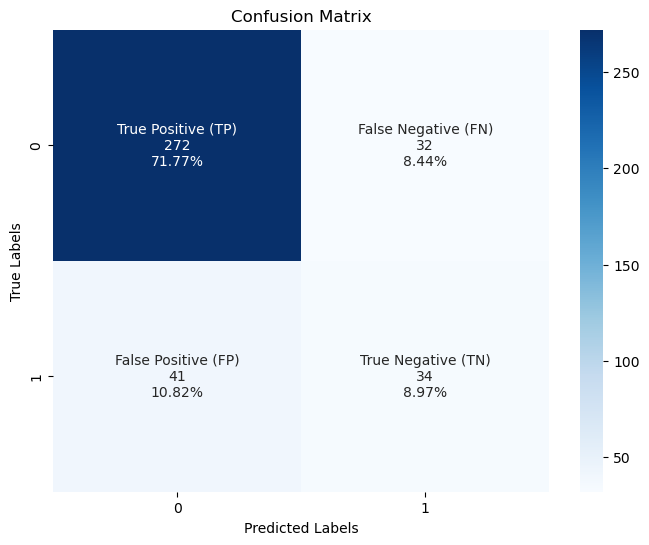

In [26]:
# Example for model_mobilenetV2
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_mobilenetV2.parameters(), lr=0.0001)

train_model(model_mobilenetV2, train_loader, criterion, optimizer, num_epochs=20)

# Example for model_mobilenetV2
accuracy, precision, recall, f1, cm = evaluate_model(model_mobilenetV2, test_loader, device)
print(f'MobilenetV2 - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}')
plot_confusion_matrix(cm, 'Confusion Matrix for model_mobilenetV2')


In [30]:
torch.save(model_mobilenetV2, 'model_mobilenetV2.pth')